<a href="https://colab.research.google.com/github/lazarosgogos/ML-exercises/blob/main/ML_Project_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import libraries

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Part 1 - Semi-supervised learning

## Q1 - Load and visualise dataset

In [11]:
wine = pd.read_csv('wine-missing.csv')
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


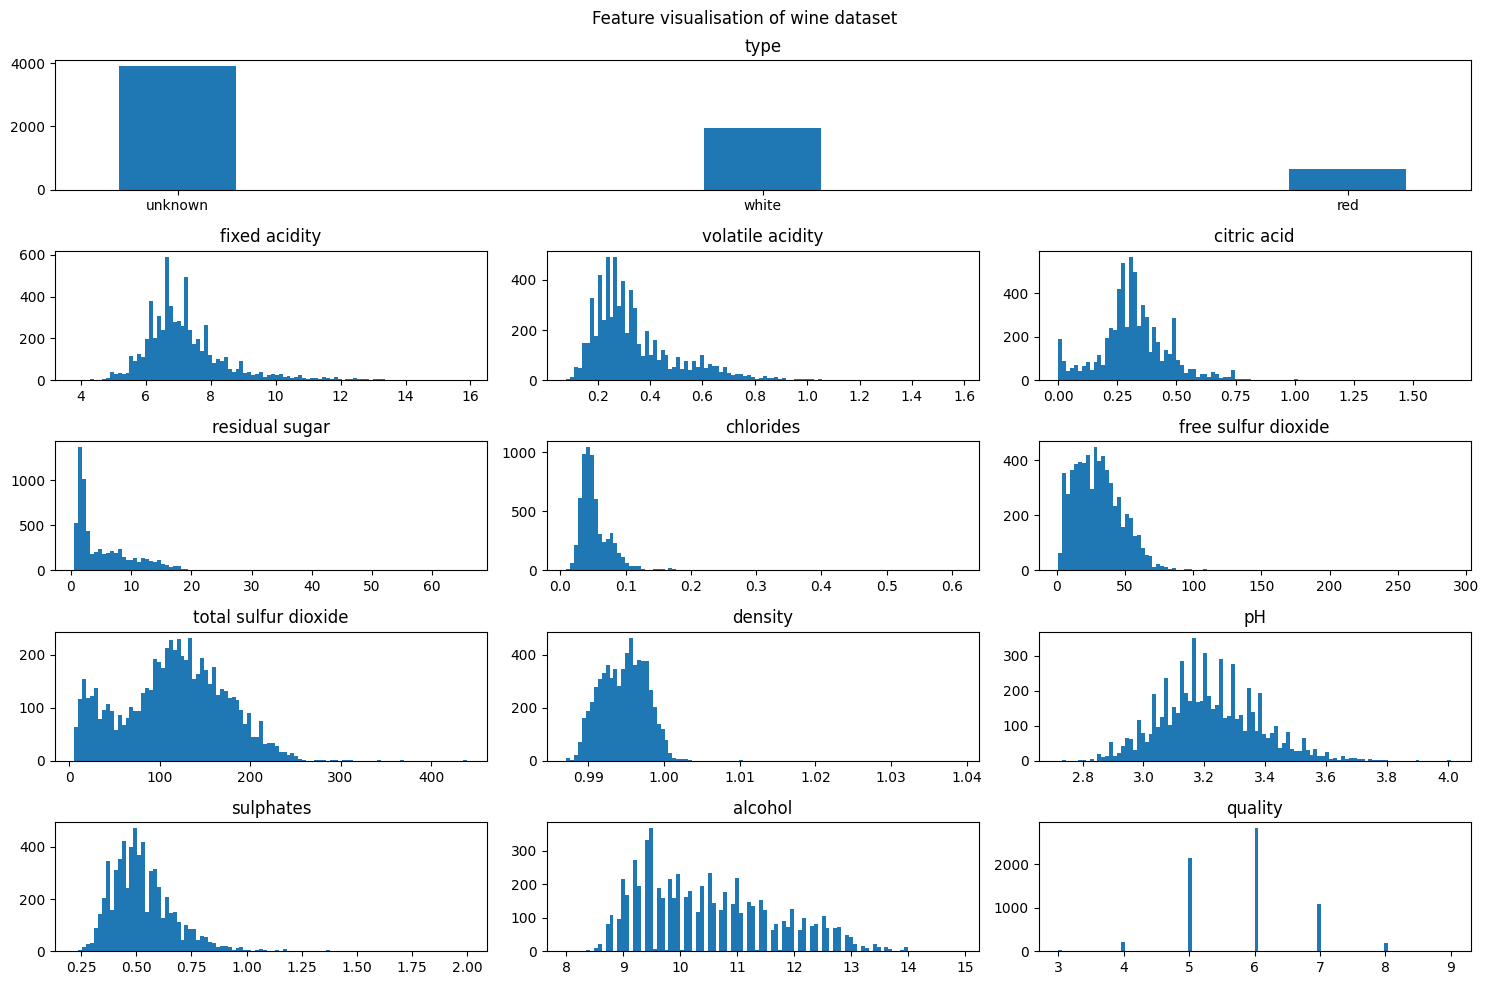

In [35]:
plt.figure(figsize=(15, 10))
for index, col in enumerate(wine.columns):
  if col == 'type':
    plt.subplot(5,1,index+1)
    plt.bar(wine[col].value_counts().index.to_list(), wine[col].value_counts(),
            width=.2)
  else:
    plt.subplot(5,3,index+3)
    plt.hist(wine[col], bins=100)
  plt.title(col)
plt.suptitle('Feature visualisation of wine dataset')
plt.tight_layout()
plt.show()

## Q2 - Target encoding and train/test dataset creation

In [61]:
target_dict = {'unknown': 0,
               'white'  : 1,
               'red'    : 2}

X = np.array(wine.drop(columns='type'))
Y = np.array(wine['type'])
Y = np.array([target_dict[y] for y in Y])

X.shape, Y.shape

((6497, 12), (6497,))

## Q3 - Separate unknown from known targets

In [68]:
mask = wine['type'] != 'unknown'
# -- VERIFY
# print(mask[0][:10])

# print(wine['type'][:15])
x_known, y_known = X[mask], Y[mask]
x_unknown = X[~mask]

## Q4 - Split dataset to stratified train and test
Για το 1o σύνολο δεδομένων, χρησιμοποιήστε τη συνάρτηση train_test_split(), ώστε να
χωρίσετε τα δεδομένα σας σε train-test με ποσοστό 70-30 αντίστοιχα. Θέστε με
random_state=42 και την επιλογή stratify=True, ώστε υπάρχει το ίδιο ποσοστό κάθε κλάσης
στα train και test αντίστοιχα.

In [70]:
test_size = .3
seed = 42
x_train, x_test, y_train, y_test = train_test_split(x_known, y_known,
                                                    test_size=test_size,
                                                    random_state=seed,
                                                    stratify=y_known)

## Q5 - Train a Random Forest Classifier; evaluate

In [78]:
rf = RandomForestClassifier(random_state=seed)
rf.fit(x_train, y_train)
y_preds = rf.predict(x_test)
accuracy = accuracy_score(y_test, y_preds)
precision, recall, f1_score, support = precision_recall_fscore_support(y_test,
                                                                       y_preds,)

print(f'Random Forest Classifier results')
print(f'  Accuracy: {accuracy:.2f}')
print(f'  Precision (for white wines): {precision[0]:.2f}')
print(f'  Precision (for red wines)  : {precision[1]:.2f}')
print(f'  Recall (for white wines)   : {recall[0]:.2f}')
print(f'  Recall (for red wines)     : {recall[1]:.2f}')
print(f'  F1-score (for white wines) : {f1_score[0]:.2f}')
print(f'  F1-score (for red wines)   : {f1_score[1]:.2f}')

Random Forest Classifier results
  Accuracy: 1.00
  Precision (for white wines): 1.00
  Precision (for red wines)  : 0.99
  Recall (for white wines)   : 1.00
  Recall (for red wines)     : 1.00
  F1-score (for white wines) : 1.00
  F1-score (for red wines)   : 1.00
